<a href="https://colab.research.google.com/github/asegura4488/FisicaA/blob/main/Semana12/Tiempo_Difusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

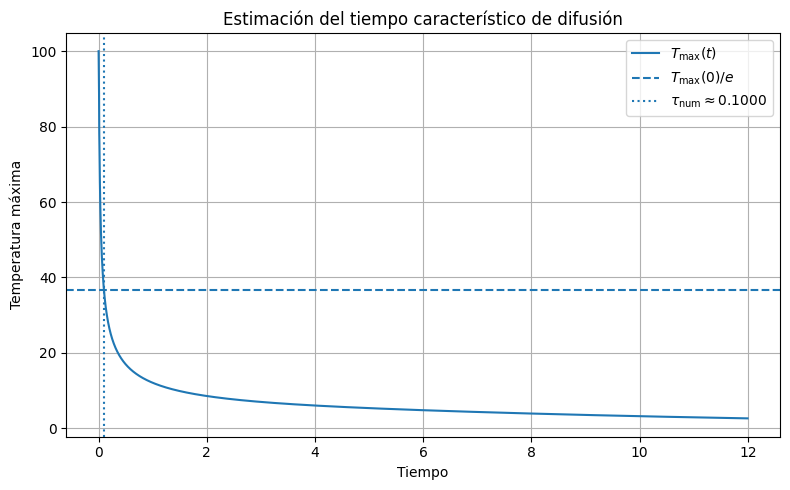

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

TIEMPO CARACTERISTICO DE DIFUSION
alpha = 0.01
L = 1.0
Estimacion teorica ~ L^2/alpha = 100.0000
Estimacion numerica por Tmax(0)/e = 0.1000


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# =====================================================
# TIEMPO CARACTERISTICO DE DIFUSION
# =====================================================

# Dominio
N = 101
L = 1.0
x = np.linspace(0, L, N)
dx = x[1] - x[0]

# Material
alpha = 0.01

# Paso temporal
dt = 0.4 * dx**2 / alpha

# Perfil inicial
T = np.zeros(N)
center = N // 2

T[center] = 100.0
T[center - 1] = 90.0
T[center + 1] = 95.0
T[center - 2] = 70.0
T[center + 2] = 75.0

Tmax0 = np.max(T)
threshold = Tmax0 / np.e

times = [0.0]
max_temps = [Tmax0]

t = 0.0
tau_num = None

for step in range(1, 3000):
    T_new = T.copy()
    T_new[0] = 0.0
    T_new[-1] = 0.0

    for i in range(1, N - 1):
        T_new[i] = T[i] + alpha * dt / dx**2 * (T[i + 1] - 2*T[i] + T[i - 1])

    T = T_new
    t += dt

    Tmax = np.max(T)
    times.append(t)
    max_temps.append(Tmax)

    if tau_num is None and Tmax <= threshold:
        tau_num = t

    if Tmax < 1e-3:
        break

plt.figure(figsize=(8, 5))
plt.plot(times, max_temps, label=r'$T_{\max}(t)$')
plt.axhline(threshold, linestyle='--', label=r'$T_{\max}(0)/e$')

if tau_num is not None:
    plt.axvline(tau_num, linestyle=':', label=fr'$\tau_{{\mathrm{{num}}}} \approx {tau_num:.4f}$')

plt.xlabel("Tiempo")
plt.ylabel("Temperatura máxima")
plt.title("Estimación del tiempo característico de difusión")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("Tiempo_Difusion.pdf", dpi=300, bbox_inches="tight")
plt.show()

files.download("Tiempo_Difusion.pdf")

tau_teorico = L**2 / alpha

print("===================================")
print("TIEMPO CARACTERISTICO DE DIFUSION")
print("===================================")
print(f"alpha = {alpha}")
print(f"L = {L}")
print(f"Estimacion teorica ~ L^2/alpha = {tau_teorico:.4f}")
if tau_num is not None:
    print(f"Estimacion numerica por Tmax(0)/e = {tau_num:.4f}")
else:
    print("No se encontro el umbral 1/e dentro del tiempo simulado.")